## Task 1 (Working code with Shuffling and it gives the best graph)




torch.Size([1999, 36])
torch.Size([1999])
torch.Size([1999, 36])
torch.Size([1999])
Training using Delta Rule (SGD)...
Accuracy:  0.6503251625812907
Accuracy:  0.4969939879759519
Training using Generalized Delta Rule (SGD with Momentum)...
Accuracy:  0.5312656328164082
Accuracy:  0.4729458917835671
Training using AdaGrad...
Accuracy:  0.5647823911955978
Accuracy:  0.5651302605210421
Training using RMSProp...
Accuracy:  0.7068534267133567
Accuracy:  0.5150300601202404
Training using Adam...
Accuracy:  0.6198099049524762
Accuracy:  0.5050100200400801


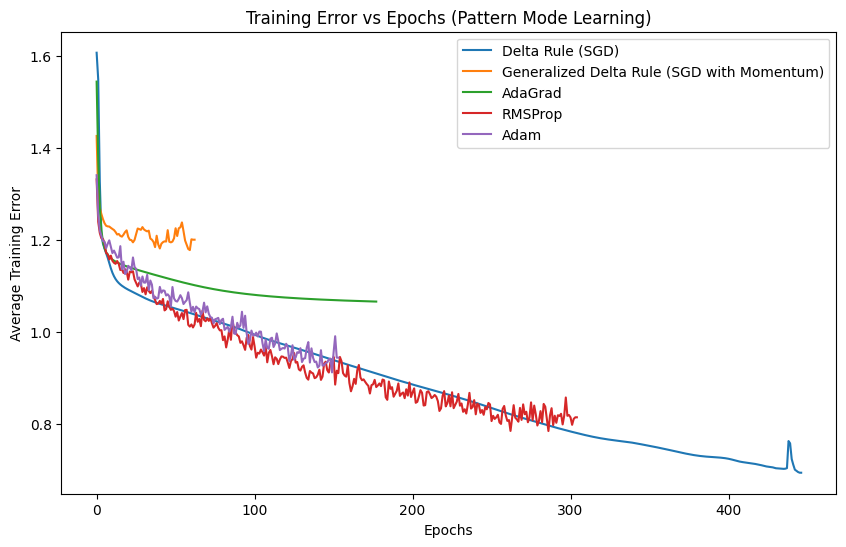

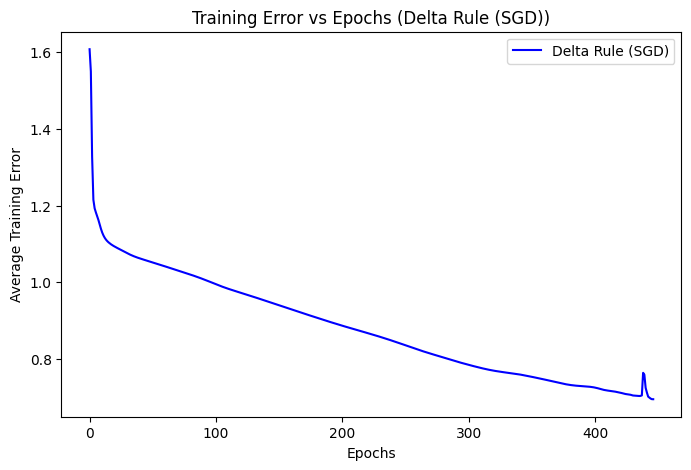

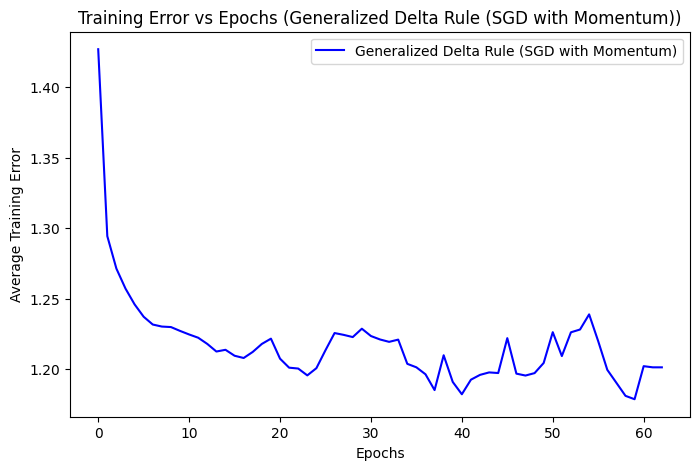

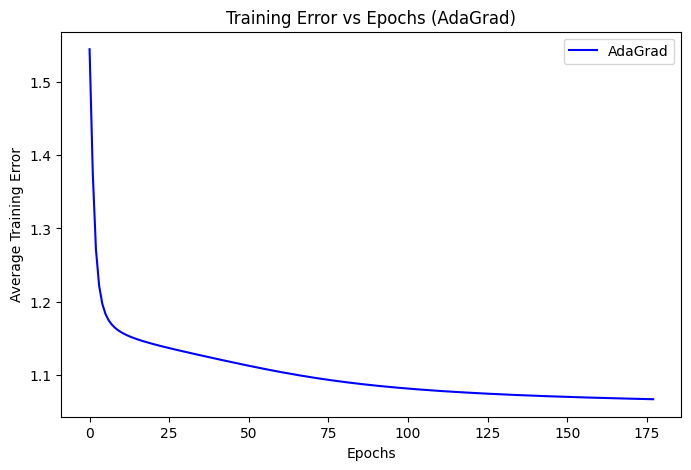

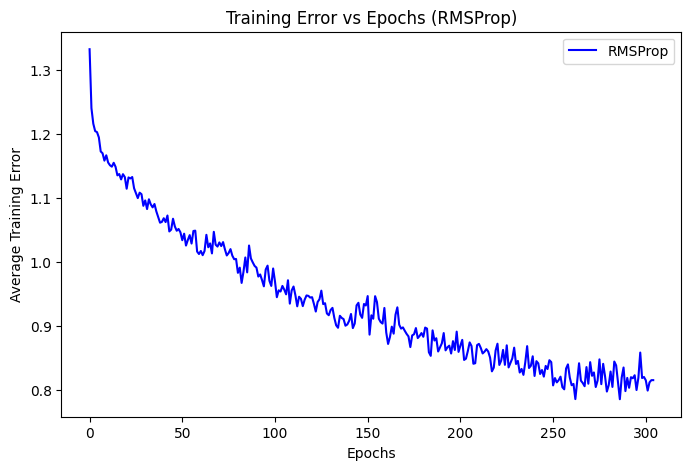

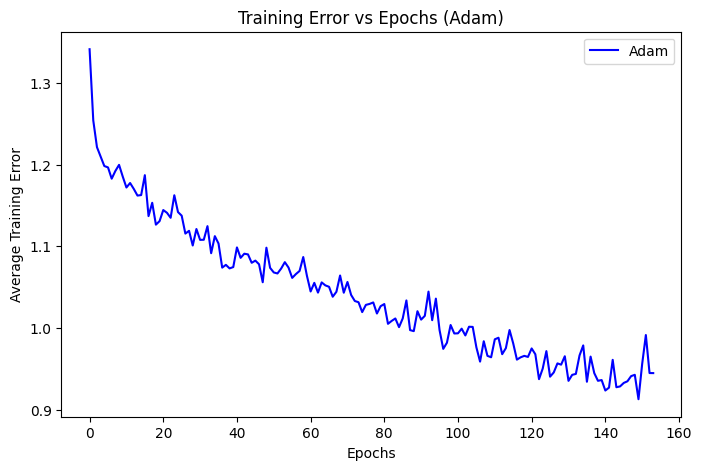

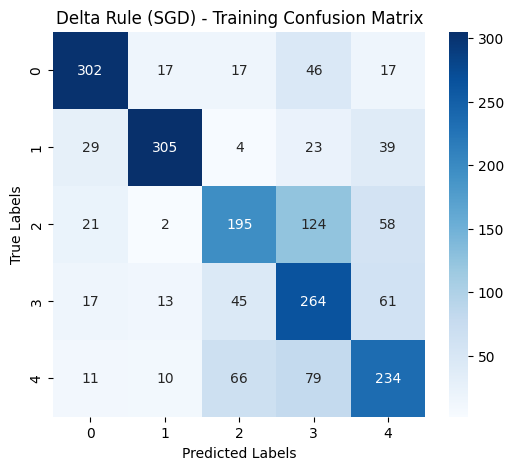

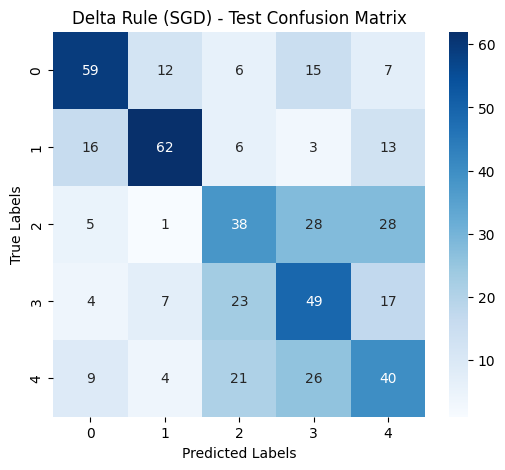

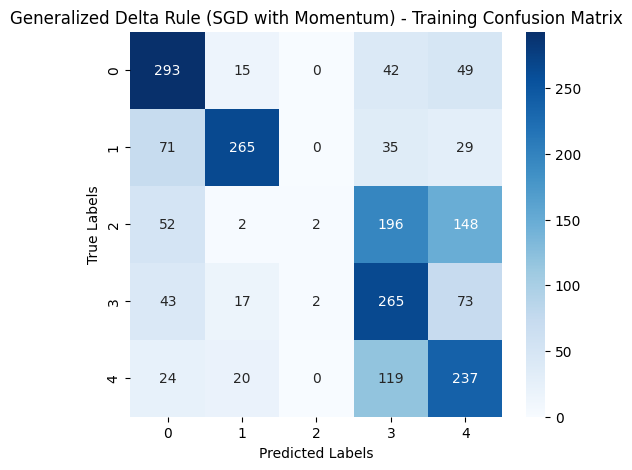

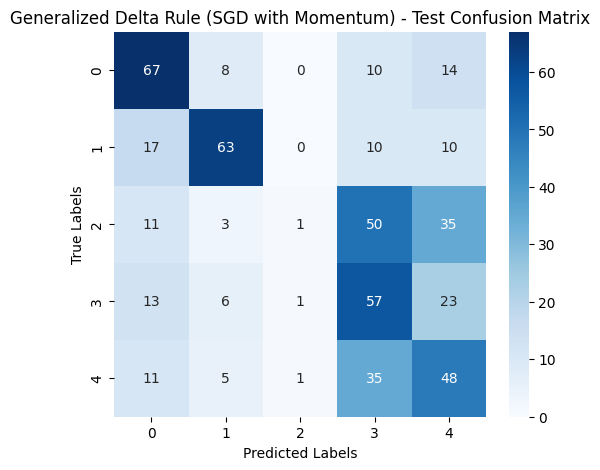

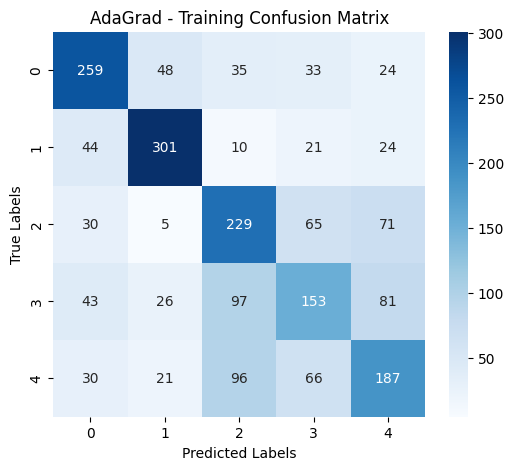

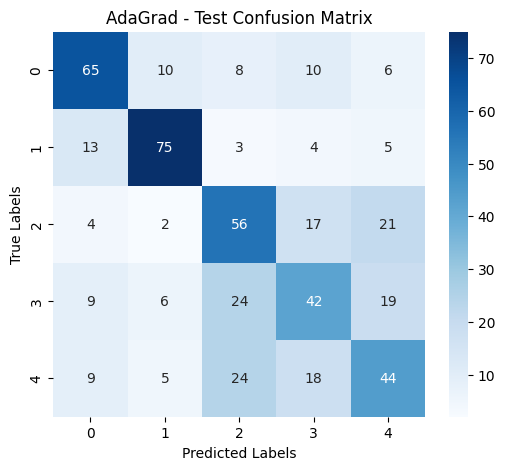

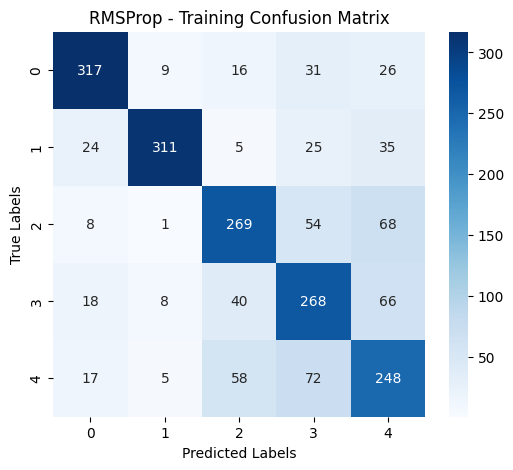

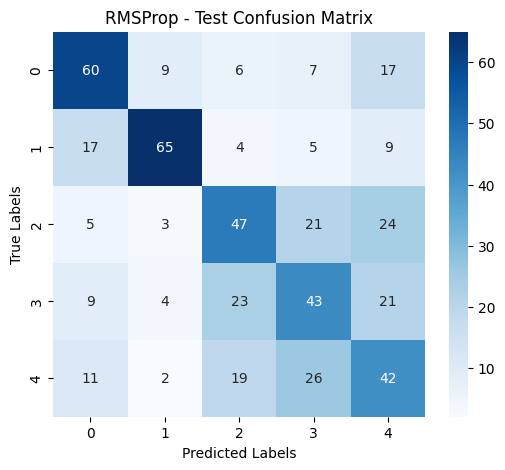

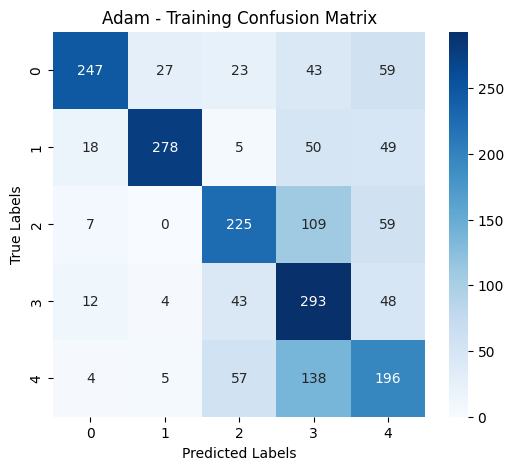

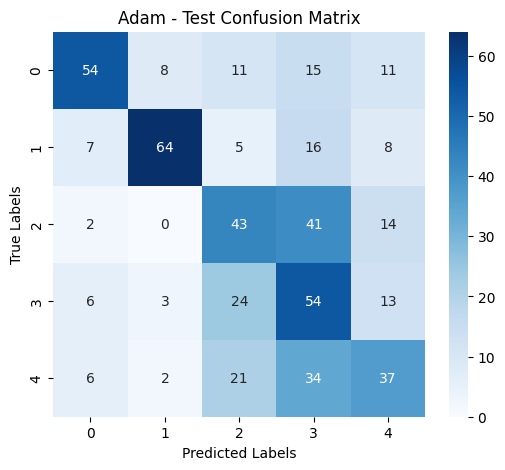

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

x_train = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task1/train_data.csv', sep=',').values
y_train = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task1/train_label.csv', sep=',').values
x_test = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task1/test_data.csv', sep=',').values
y_test = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task1/test_label.csv', sep=',').values
x_val = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task1/val_data.csv', sep=',').values
y_val = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task1/val_label.csv', sep=',').values


x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train.flatten(), dtype=torch.long)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test.flatten(), dtype=torch.long)
x_val = torch.tensor(x_val, dtype=torch.float32)
y_val = torch.tensor(y_val.flatten(), dtype=torch.long)

print(x_train.shape)
print(y_train.shape)
indices = torch.randperm(x_train.size(0))
x_train = x_train[indices]
y_train = y_train[indices]
print(x_train.shape)
print(y_train.shape)


# Defing the model with 2 hidden layer
class MLFFNN(nn.Module):
    def __init__(self, input_size=36, hidden1_size=20, hidden2_size=10, output_size=5):
        super(MLFFNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden1_size)
        self.fc2 = nn.Linear(hidden1_size, hidden2_size)
        self.fc3 = nn.Linear(hidden2_size, output_size)
        self.tanh = nn.Tanh()

    def forward(self, x):
        x = self.tanh(self.fc1(x))
        x = self.tanh(self.fc2(x))
        x = self.fc3(x)
        return x


def train_model(model, optimizer, x_train, y_train, criterion, max_epochs=1000, threshold=1e-4):
    train_errors = []
    prev_avg_error = float('inf')

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0.0

        for i in range(len(x_train)):
            input_sample = x_train[i].unsqueeze(0)
            label_sample = y_train[i].unsqueeze(0)

            optimizer.zero_grad()
            output = model(input_sample)
            loss = criterion(output, label_sample)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_error = epoch_loss / len(x_train)
        train_errors.append(avg_error)
        #print(f"Epoch {epoch+1}/{max_epochs}, Average Training Error: {avg_error:.4f}")
        # Stopping criterion
        if abs(prev_avg_error - avg_error) < threshold:
            break

        prev_avg_error = avg_error

    return train_errors, epoch

def evaluate_model(model, x_data, y_data):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for i in range(len(x_data)):
            input_sample = x_data[i].unsqueeze(0)
            output = model(input_sample)
            output = torch.softmax(output,dim=1)
            _, predicted = torch.max(output, 1)
            #print(predicted)
            all_preds.append(predicted.item())
            all_labels.append(y_data[i].item())
    print("Accuracy: ",accuracy_score(y_data,all_preds));
    return confusion_matrix(all_labels, all_preds)

criterion = nn.CrossEntropyLoss()

optimizers = {
    "Delta Rule (SGD)": optim.SGD,
    "Generalized Delta Rule (SGD with Momentum)":optim.SGD,
    "AdaGrad": optim.Adagrad,
    "RMSProp": optim.RMSprop,
    "Adam": optim.Adam
}

learning_rate = 0.01
results = {}

for name, optim_fn in optimizers.items():
    print(f"Training using {name}...")
    torch.manual_seed(42)
    model = MLFFNN(input_size=36, output_size=5)
    if(name=="Generalized Delta Rule (SGD with Momentum)"):
      optimizer = optim_fn(model.parameters(), lr=learning_rate,momentum=0.9)
    else:
      optimizer = optim_fn(model.parameters(), lr=learning_rate)

    train_errors, epochs = train_model(model, optimizer, x_train, y_train, criterion)
    train_conf_matrix = evaluate_model(model, x_train, y_train)
    test_conf_matrix = evaluate_model(model, x_test, y_test)

    results[name] = {
        "train_errors": train_errors,
        "epochs": epochs,
        "train_conf_matrix": train_conf_matrix,
        "test_conf_matrix": test_conf_matrix
    }


plt.figure(figsize=(10, 6))
for name, res in results.items():
    plt.plot(range(len(res["train_errors"])), res["train_errors"], label=name)
plt.xlabel("Epochs")
plt.ylabel("Average Training Error")
plt.title("Training Error vs Epochs (Pattern Mode Learning)")
plt.legend()
plt.show()


# Plot training error vs epochs in a separate graph
for name, res in results.items():
    plt.figure(figsize=(8, 5))
    plt.plot(range(len(res["train_errors"])), res["train_errors"], label=name, color='b')
    plt.xlabel("Epochs")
    plt.ylabel("Average Training Error")
    plt.title(f"Training Error vs Epochs ({name})")
    plt.legend()
    plt.show()



for name, res in results.items():
    plt.figure(figsize=(6, 5))
    sns.heatmap(res["train_conf_matrix"], annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Training Confusion Matrix")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()

    plt.figure(figsize=(6, 5))
    sns.heatmap(res["test_conf_matrix"], annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Test Confusion Matrix")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()




## Batch mode of learning with different weight update rule

Training using Delta Rule (SGD)...
Epoch 0: Avg Error = 1.617208
Accuracy:  0.19409704852426213
Accuracy:  0.19438877755511022
Training using Generalized Delta Rule (SGD with Momentum)...
Epoch 0: Avg Error = 1.617208
Accuracy:  0.19409704852426213
Accuracy:  0.19438877755511022
Training using AdaGrad...
Epoch 0: Avg Error = 1.617208
Epoch 50: Avg Error = 1.291809
Epoch 100: Avg Error = 1.189433
Epoch 150: Avg Error = 1.155044
Epoch 200: Avg Error = 1.134179
Epoch 250: Avg Error = 1.117612
Epoch 300: Avg Error = 1.103960
Epoch 350: Avg Error = 1.092774
Epoch 400: Avg Error = 1.083522
Epoch 450: Avg Error = 1.075846
Epoch 500: Avg Error = 1.069570
Accuracy:  0.568784392196098
Accuracy:  0.561122244488978
Training using RMSProp...
Epoch 0: Avg Error = 1.617208
Accuracy:  0.512256128064032
Accuracy:  0.533066132264529
Training using Adam...
Epoch 0: Avg Error = 1.617208
Epoch 50: Avg Error = 1.096049
Epoch 100: Avg Error = 1.036864
Accuracy:  0.5847923961980991
Accuracy:  0.55110220440881

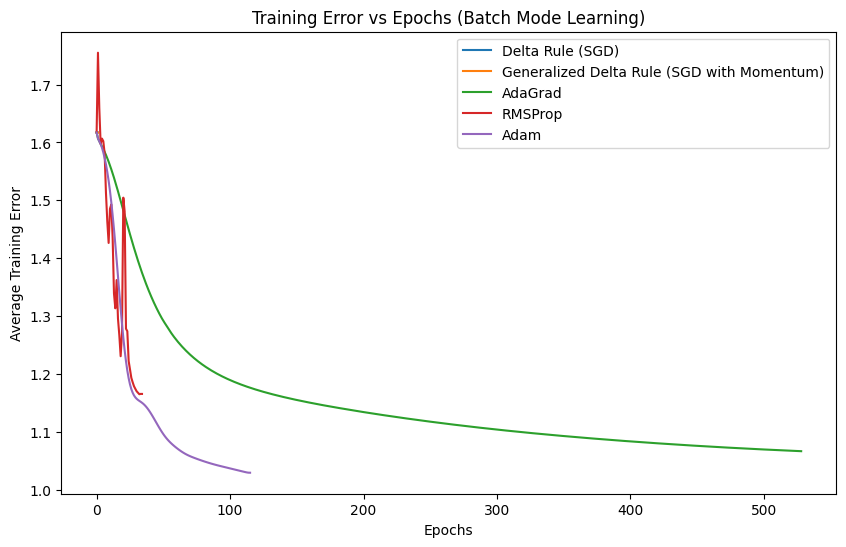

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

# Load dataset from CSV
x_train = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task1/train_data.csv', sep=',').values
y_train = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task1/train_label.csv', sep=',').values
x_test = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task1/test_data.csv', sep=',').values
y_test = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task1/test_label.csv', sep=',').values
x_val = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task1/val_data.csv', sep=',').values
y_val = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task1/val_label.csv', sep=',').values

# Convert to PyTorch tensors
x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train.flatten(), dtype=torch.long)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test.flatten(), dtype=torch.long)
x_val = torch.tensor(x_val, dtype=torch.float32)
y_val = torch.tensor(y_val.flatten(), dtype=torch.long)

# Shuffle training data
indices = torch.randperm(x_train.size(0))
x_train = x_train[indices]
y_train = y_train[indices]

# Define MLFFNN Model
class MLFFNN(nn.Module):
    def __init__(self, input_size=36, hidden1_size=20, hidden2_size=10, output_size=5):
        super(MLFFNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden1_size)
        self.fc2 = nn.Linear(hidden1_size, hidden2_size)
        self.fc3 = nn.Linear(hidden2_size, output_size)
        self.tanh = nn.Tanh()

    def forward(self, x):
        x = self.tanh(self.fc1(x))
        x = self.tanh(self.fc2(x))
        x = self.fc3(x)  # No activation in output (CrossEntropyLoss expects raw logits)
        return x

# Train function (Fully Batch Mode Learning)
def train_model_batch(model, optimizer, x_train, y_train, criterion, max_epochs=1000, threshold=1e-4):
    train_errors = []
    prev_avg_error = float('inf')

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()  # Reset gradients

        output = model(x_train)  # Forward pass over entire batch
        loss = criterion(output, y_train)  # Compute loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights

        avg_error = loss.item()  # Store the loss for tracking
        train_errors.append(avg_error)

        if epoch % 50 == 0:
            print(f"Epoch {epoch}: Avg Error = {avg_error:.6f}")

        # Stopping criterion
        if abs(prev_avg_error - avg_error) < threshold:
            break

        prev_avg_error = avg_error

    return train_errors, epoch

# Evaluation function
def evaluate_model(model, x_data, y_data):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        output = model(x_data)  # Forward pass over entire dataset
        output = torch.softmax(output, dim=1)  # Convert logits to probabilities
        _, predicted = torch.max(output, 1)  # Get predicted class labels
        all_preds = predicted.tolist()
        all_labels = y_data.tolist()

    print("Accuracy: ", accuracy_score(y_data, all_preds))
    return confusion_matrix(all_labels, all_preds)

# Define loss function
criterion = nn.CrossEntropyLoss()

# Optimization methods
optimizers = {
    "Delta Rule (SGD)": optim.SGD,
    "Generalized Delta Rule (SGD with Momentum)": optim.SGD,
    "AdaGrad": optim.Adagrad,
    "RMSProp": optim.RMSprop,
    "Adam": optim.Adam
}

learning_rate = 0.01
results = {}

# Training and Evaluation
for name, optim_fn in optimizers.items():
    print(f"Training using {name}...")
    torch.manual_seed(42)
    model = MLFFNN(input_size=36, output_size=5)

    if name == "Generalized Delta Rule (SGD with Momentum)":
        optimizer = optim_fn(model.parameters(), lr=learning_rate, momentum=0.9)
    else:
        optimizer = optim_fn(model.parameters(), lr=learning_rate)

    train_errors, epochs = train_model_batch(model, optimizer, x_train, y_train, criterion)
    train_conf_matrix = evaluate_model(model, x_train, y_train)
    test_conf_matrix = evaluate_model(model, x_test, y_test)

    results[name] = {
        "train_errors": train_errors,
        "epochs": epochs,
        "train_conf_matrix": train_conf_matrix,
        "test_conf_matrix": test_conf_matrix
    }

# Plot training error vs epochs
plt.figure(figsize=(10, 6))
for name, res in results.items():
    plt.plot(range(len(res["train_errors"])), res["train_errors"], label=name)
plt.xlabel("Epochs")
plt.ylabel("Average Training Error")
plt.title("Training Error vs Epochs (Batch Mode Learning)")
plt.legend()
plt.show()


## Batch mode of learning with different weight update rule and batch size 200

Training using Delta Rule (SGD)...
Epoch 0: Avg Error = 1.796608
Accuracy:  0.20410205102551277
Accuracy:  0.18837675350701402
Training using Generalized Delta Rule (SGD with Momentum)...
Epoch 0: Avg Error = 1.796061
Epoch 50: Avg Error = 1.443296
Epoch 100: Avg Error = 1.266538
Accuracy:  0.5202601300650325
Accuracy:  0.5050100200400801
Training using AdaGrad...
Epoch 0: Avg Error = 1.780296
Epoch 50: Avg Error = 1.270278
Accuracy:  0.5172586293146574
Accuracy:  0.5270541082164328
Training using RMSProp...
Epoch 0: Avg Error = 1.787877
Epoch 50: Avg Error = 1.167455
Epoch 100: Avg Error = 1.130181
Accuracy:  0.6013006503251626
Accuracy:  0.5571142284569138
Training using Adam...
Epoch 0: Avg Error = 1.775898
Epoch 50: Avg Error = 1.150185
Accuracy:  0.5857928964482241
Accuracy:  0.5551102204408818


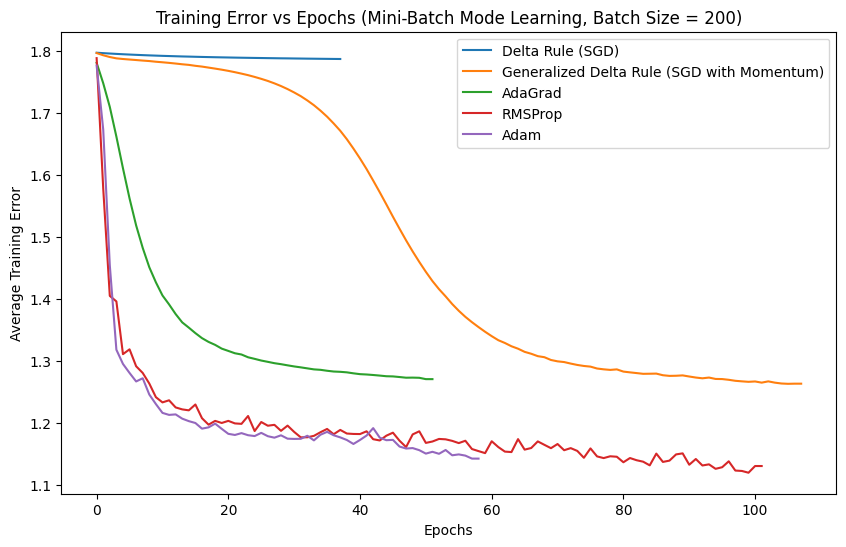

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

# Load dataset from CSV
x_train = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task1/train_data.csv', sep=',').values
y_train = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task1/train_label.csv', sep=',').values
x_test = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task1/test_data.csv', sep=',').values
y_test = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task1/test_label.csv', sep=',').values
x_val = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task1/val_data.csv', sep=',').values
y_val = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task1/val_label.csv', sep=',').values

# Convert to PyTorch tensors
x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train.flatten(), dtype=torch.long)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test.flatten(), dtype=torch.long)
x_val = torch.tensor(x_val, dtype=torch.float32)
y_val = torch.tensor(y_val.flatten(), dtype=torch.long)

# Define batch size
batch_size = 200

# Define MLFFNN Model
class MLFFNN(nn.Module):
    def __init__(self, input_size=36, hidden1_size=20, hidden2_size=10, output_size=5):
        super(MLFFNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden1_size)
        self.fc2 = nn.Linear(hidden1_size, hidden2_size)
        self.fc3 = nn.Linear(hidden2_size, output_size)
        self.tanh = nn.Tanh()

    def forward(self, x):
        x = self.tanh(self.fc1(x))
        x = self.tanh(self.fc2(x))
        x = self.fc3(x)  # No activation in output (CrossEntropyLoss expects raw logits)
        return x

# Train function (Mini-Batch Mode Learning)
def train_model_minibatch(model, optimizer, x_train, y_train, criterion, batch_size=200, max_epochs=1000, threshold=1e-4):
    train_errors = []
    prev_avg_error = float('inf')

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0.0
        num_batches = len(x_train) // batch_size

        # Shuffle data
        indices = torch.randperm(x_train.size(0))
        x_train = x_train[indices]
        y_train = y_train[indices]

        for i in range(0, len(x_train), batch_size):
            x_batch = x_train[i:i+batch_size]
            y_batch = y_train[i:i+batch_size]

            optimizer.zero_grad()
            output = model(x_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_error = epoch_loss / num_batches
        train_errors.append(avg_error)

        if epoch % 50 == 0:
            print(f"Epoch {epoch}: Avg Error = {avg_error:.6f}")

        # Stopping criterion
        if abs(prev_avg_error - avg_error) < threshold:
            break

        prev_avg_error = avg_error

    return train_errors, epoch

# Evaluation function
def evaluate_model(model, x_data, y_data):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        output = model(x_data)  # Forward pass over entire dataset
        output = torch.softmax(output, dim=1)  # Convert logits to probabilities
        _, predicted = torch.max(output, 1)  # Get predicted class labels
        all_preds = predicted.tolist()
        all_labels = y_data.tolist()

    print("Accuracy: ", accuracy_score(y_data, all_preds))
    return confusion_matrix(all_labels, all_preds)

# Define loss function
criterion = nn.CrossEntropyLoss()

# Optimization methods
optimizers = {
    "Delta Rule (SGD)": optim.SGD,
    "Generalized Delta Rule (SGD with Momentum)": optim.SGD,
    "AdaGrad": optim.Adagrad,
    "RMSProp": optim.RMSprop,
    "Adam": optim.Adam
}

learning_rate = 0.01
results = {}

# Training and Evaluation
for name, optim_fn in optimizers.items():
    print(f"Training using {name}...")
    torch.manual_seed(42)
    model = MLFFNN(input_size=36, output_size=5)

    if name == "Generalized Delta Rule (SGD with Momentum)":
        optimizer = optim_fn(model.parameters(), lr=learning_rate, momentum=0.9)
    else:
        optimizer = optim_fn(model.parameters(), lr=learning_rate)

    train_errors, epochs = train_model_minibatch(model, optimizer, x_train, y_train, criterion, batch_size=batch_size)
    train_conf_matrix = evaluate_model(model, x_train, y_train)
    test_conf_matrix = evaluate_model(model, x_test, y_test)

    results[name] = {
        "train_errors": train_errors,
        "epochs": epochs,
        "train_conf_matrix": train_conf_matrix,
        "test_conf_matrix": test_conf_matrix
    }

# Plot training error vs epochs
plt.figure(figsize=(10, 6))
for name, res in results.items():
    plt.plot(range(len(res["train_errors"])), res["train_errors"], label=name)
plt.xlabel("Epochs")
plt.ylabel("Average Training Error")
plt.title("Training Error vs Epochs (Mini-Batch Mode Learning, Batch Size = 200)")
plt.legend()
plt.show()


## Task 2

Training using No Normalization...
Accuracy Score 0.624312156078039
Accuracy Score 0.3807615230460922
Training using Layer Normalization...
Accuracy Score 0.5732866433216608
Accuracy Score 0.3667334669338677
Training using Batch Normalization (Post-Activation)...
Accuracy Score 0.6258129064532266
Accuracy Score 0.3727454909819639


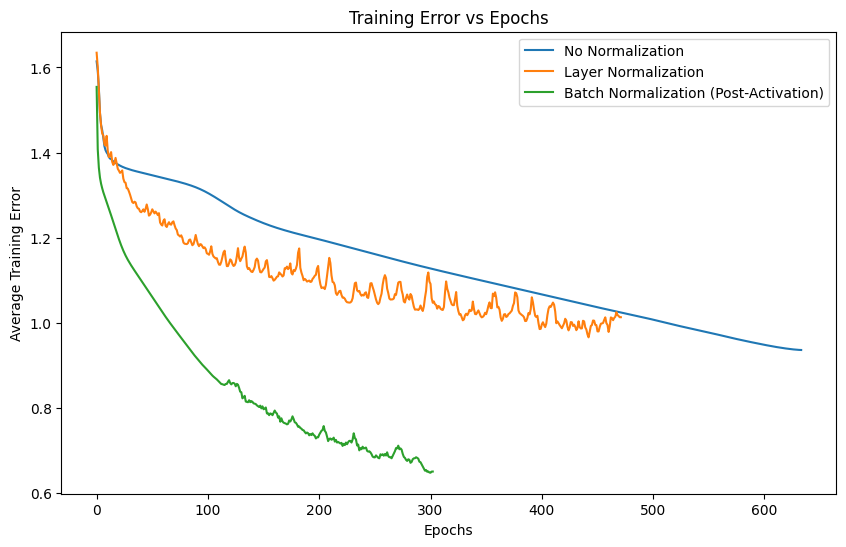

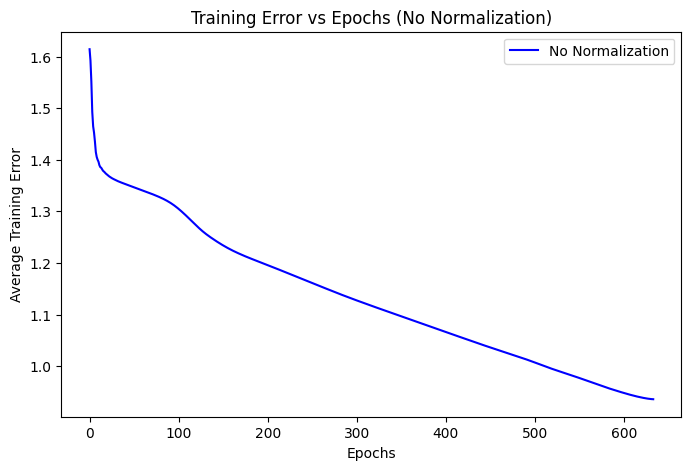

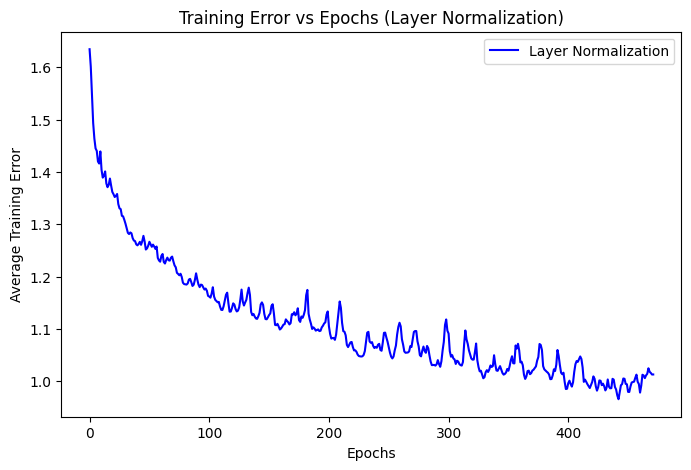

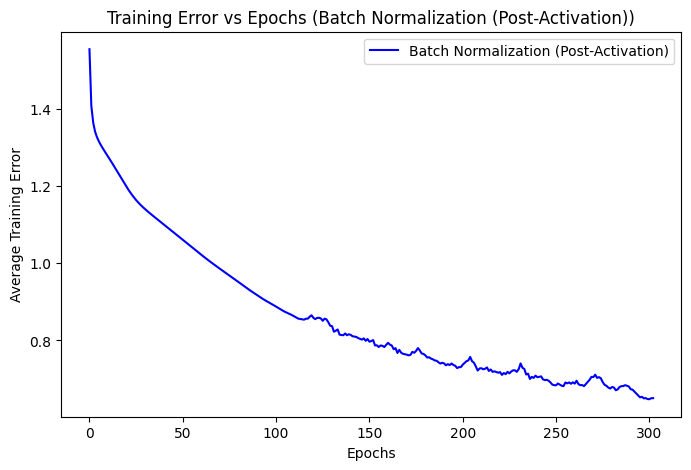

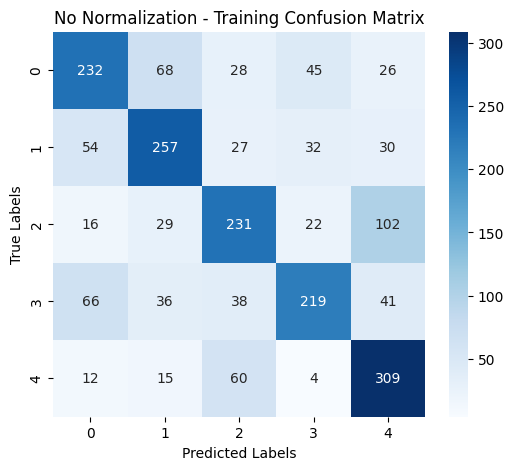

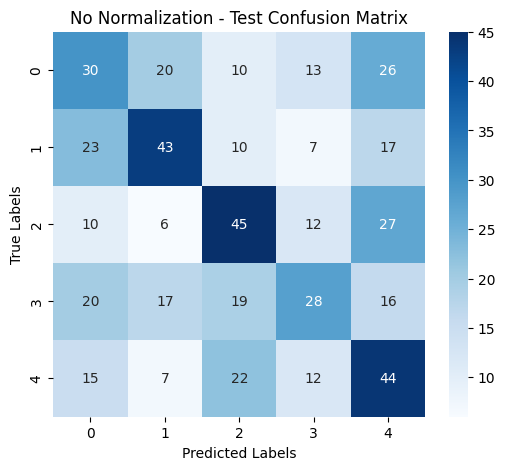

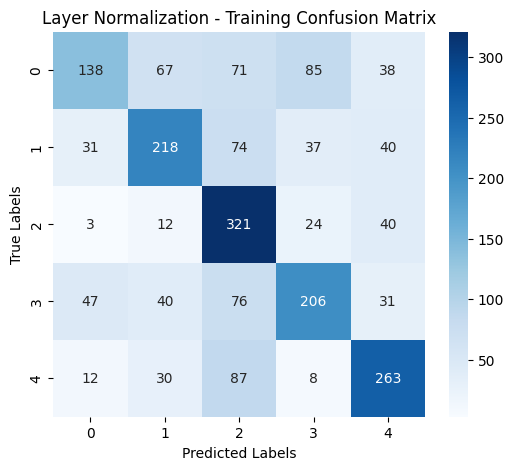

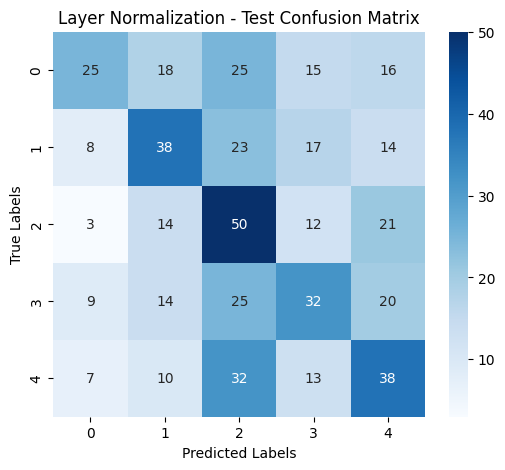

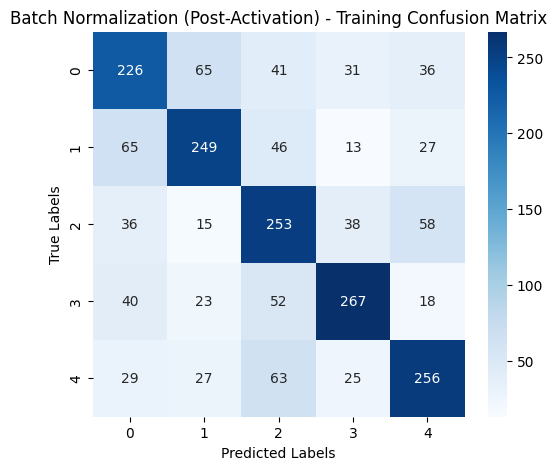

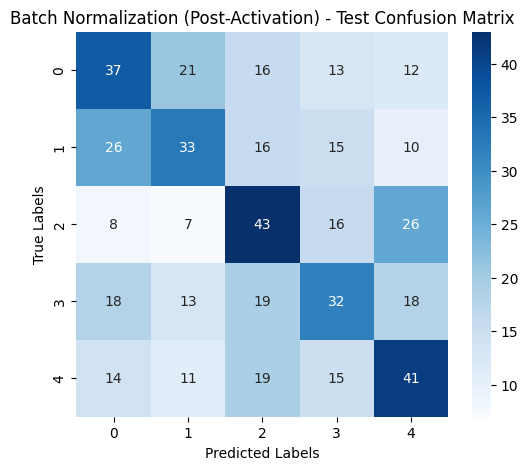

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix,accuracy_score
from torch.utils.data import DataLoader, TensorDataset


x_train = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task2/train_data.csv', sep=',').values
y_train = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task2/train_label.csv', sep=',').values
x_test = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task2/test_data.csv', sep=',').values
y_test = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task2/test_label.csv', sep=',').values
x_val = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task2/val_data.csv', sep=',').values
y_val = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task2/val_label.csv', sep=',').values

# Converting all datasets to PyTorch tensors
x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train.flatten(), dtype=torch.long)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test.flatten(), dtype=torch.long)
x_val = torch.tensor(x_val, dtype=torch.float32)
y_val = torch.tensor(y_val.flatten(), dtype=torch.long)

# Code to shuffle the dataset before training
indices = torch.randperm(x_train.size(0))
x_train = x_train[indices]
y_train = y_train[indices]


train_dataset = TensorDataset(x_train, y_train)
test_dataset = TensorDataset(x_test, y_test)
val_dataset = TensorDataset(x_val, y_val)

batch_sz=int(math.ceil(x_train.shape[0]/10))

train_loader = DataLoader(train_dataset, batch_size=batch_sz, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_sz, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_sz, shuffle=False)


class MLFFNN(nn.Module):
    def __init__(self, input_size=36, hidden1_size=20, hidden2_size=10, output_size=5, normalization="none"):
        super(MLFFNN, self).__init__()

        self.fc1 = nn.Linear(input_size, hidden1_size)
        self.fc2 = nn.Linear(hidden1_size, hidden2_size)
        self.fc3 = nn.Linear(hidden2_size, output_size)

        self.tanh = nn.Tanh()

        # Set the normalization based on the normalization parameter passed by user
        self.normalization = normalization
        if normalization == "layer_norm":
            self.norm1 = nn.LayerNorm(hidden1_size)
            self.norm2 = nn.LayerNorm(hidden2_size)
        elif normalization == "batch_norm":
            self.norm1 = nn.BatchNorm1d(hidden1_size)
            self.norm2 = nn.BatchNorm1d(hidden2_size)

    def forward(self, x):
        if self.normalization=="layer_norm":
          x=self.fc1(x)
          x=self.tanh(x)
          x=self.norm1(x)

          x=self.fc2(x)
          x=self.tanh(x)
          x=self.norm2(x)
          x=self.fc3(x)

        elif self.normalization=="batch_norm":
          x=self.fc1(x)
          x=self.tanh(x)
          x=self.norm1(x)

          x=self.fc2(x)
          x=self.tanh(x)
          x=self.norm2(x)

          x=self.fc3(x)
        else:
          x=self.fc1(x)
          x=self.tanh(x)
          x=self.fc2(x)
          x=self.tanh(x)
          x=self.fc3(x)
        return x

def train_model(model, train_loader, criterion, optimizer, max_epochs=1000, threshold=1e-4):
    train_errors = []
    prev_avg_error = float('inf')

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0.0

        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * inputs.size(0)

        avg_error = epoch_loss / len(train_loader.dataset)
        train_errors.append(avg_error)

        if abs(prev_avg_error - avg_error) < threshold:
            break

        prev_avg_error = avg_error


    return train_errors, epoch

# Test function
def evaluate_model(model, x_data, y_data):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for i in range(len(x_data)):
            input_sample = x_data[i].unsqueeze(0)
            output = model(input_sample)
            output = torch.softmax(output,dim=1)
            _, predicted = torch.max(output, 1)
            all_preds.append(predicted.item())
            all_labels.append(y_data[i].item())
    print("Accuracy Score",accuracy_score(y_data,all_preds))
    return confusion_matrix(all_labels, all_preds)


criterion = nn.CrossEntropyLoss()
learning_rate = 0.01
results = {}


normalization_methods = {
    "No Normalization": "none",
    "Layer Normalization": "layer_norm",
    "Batch Normalization (Post-Activation)": "batch_norm"
}

for name, norm_type in normalization_methods.items():
    print(f"Training using {name}...")

    model = MLFFNN(input_size=36, output_size=5, normalization=norm_type)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_errors, epochs = train_model(model, train_loader, criterion, optimizer)
    train_conf_matrix = evaluate_model(model, x_train, y_train)
    test_conf_matrix = evaluate_model(model, x_test, y_test)

    results[name] = {
        "train_errors": train_errors,
        "epochs": epochs,
        "train_conf_matrix": train_conf_matrix,
        "test_conf_matrix": test_conf_matrix
    }

# Plot training error vs epochs in single graph
plt.figure(figsize=(10, 6))
for name, res in results.items():
    plt.plot(range(len(res["train_errors"])), res["train_errors"], label=name)
plt.xlabel("Epochs")
plt.ylabel("Average Training Error")
plt.title("Training Error vs Epochs")
plt.legend()
plt.show()

# Plot training error vs epochs in individual graph
for name, res in results.items():
    plt.figure(figsize=(8, 5))
    plt.plot(range(len(res["train_errors"])), res["train_errors"], label=name, color='b')
    plt.xlabel("Epochs")
    plt.ylabel("Average Training Error")
    plt.title(f"Training Error vs Epochs ({name})")
    plt.legend()
    plt.show()


for name, res in results.items():
    plt.figure(figsize=(6, 5))
    sns.heatmap(res["train_conf_matrix"], annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Training Confusion Matrix")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()

    plt.figure(figsize=(6, 5))
    sns.heatmap(res["test_conf_matrix"], annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Test Confusion Matrix")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()



# Task 3

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score


x_train = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task3/train_labeled_data.csv', sep=',').values
y_train = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task3/train_labeled_labels.csv', sep=',').values
x_train_unlabel = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task3/train_unlabeled.csv', sep=',').values
x_test = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task3/test_data.csv', sep=',').values
y_test = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task3/test_labels.csv', sep=',').values
x_val = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task3/val_data.csv', sep=',').values
y_val = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task3/val_labels.csv', sep=',').values


x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train.flatten(), dtype=torch.long)
x_train_unlabel = torch.tensor(x_train_unlabel, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test.flatten(), dtype=torch.long)
x_val = torch.tensor(x_val, dtype=torch.float32)
y_val = torch.tensor(y_val.flatten(), dtype=torch.long)

indices = torch.randperm(x_train.size(0))
x_train = x_train[indices]
x_train_unlabel=x_train_unlabel[indices]
y_train = y_train[indices]

train_dataset = TensorDataset(x_train, y_train)
train_unlabel_dataset = TensorDataset(x_train_unlabel,x_train_unlabel)
test_dataset = TensorDataset(x_test, y_test)
val_dataset = TensorDataset(x_val, y_val)

batch_sz=int(math.ceil(x_train.shape[0]/10))

train_loader = DataLoader(train_dataset, batch_size=batch_sz, shuffle=False)
train_unlabel_loader = DataLoader(train_unlabel_dataset, batch_size=batch_sz, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_sz, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_sz, shuffle=False)

print(x_train.shape)
print(x_train_unlabel.shape)
print(y_train.shape)
print(torch.unique(y_train))

torch.Size([749, 36])
torch.Size([749, 36])
torch.Size([749])
tensor([0, 1, 2, 3, 4])


## Decide no of hidden layers.

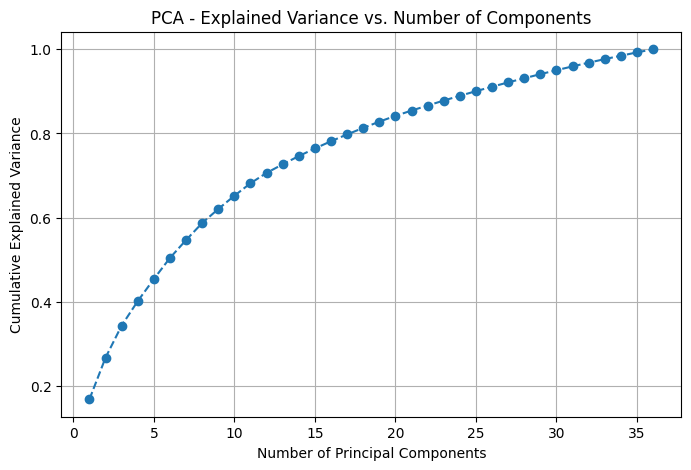

Optimal number of dimensions to retain 95% variance: 30


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load your unlabeled dataset
# Replace this with actual dataset loading
data = pd.read_csv('/content/drive/MyDrive/DL/A1/team6/task3/train_unlabeled.csv', sep=',').values

# Step 1: Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Step 2: Apply PCA
pca = PCA()
pca.fit(data_scaled)

# Step 3: Plot explained variance to find optimal number of components
explained_variance_ratio = np.cumsum(pca.explained_variance_ratio_)  # Cumulative sum of variance

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance vs. Number of Components')
plt.grid()
plt.show()

# Step 4: Select the number of dimensions that explain 95% variance
optimal_dims = np.argmax(explained_variance_ratio >= 0.95) + 1
print(f"Optimal number of dimensions to retain 95% variance: {optimal_dims}")


## AutoEncoder class

In [ ]:
# Define Autoencoder Class
class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim,bottleneck_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim,bottleneck_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [ ]:
def train_autoencoder(autoencoder, train_loader, epochs=1000, lr=0.001, threshold=1e-4):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(autoencoder.parameters(), lr=lr)

    prev_avg_error = float('inf')
    train_errors = []

    for epoch in range(epochs):
        autoencoder.train()
        epoch_loss = 0.0

        for inputs in train_loader:
            inputs = inputs[0]
            optimizer.zero_grad()
            output = autoencoder(inputs)
            loss = criterion(output, inputs)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * inputs.size(0)

        avg_error = epoch_loss / len(train_loader.dataset)
        train_errors.append(avg_error)
        print(f"Epoch {epoch+1}/{epochs}, Average Error: {avg_error}")

        if abs(prev_avg_error - avg_error) < threshold:
            break

        prev_avg_error = avg_error
    print(autoencoder.encoder)
    print(autoencoder.encoder[0].weight.data.shape)
    print(autoencoder.encoder[2].weight.data.shape)
    return autoencoder.encoder


## DFNN Class

In [ ]:
class DFNN(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim, label_count):
        super(DFNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dims[0])
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.fc3 = nn.Linear(hidden_dims[1], hidden_dims[2])
        self.fc4 = nn.Linear(hidden_dims[2], output_dim)
        self.fc5 = nn.Linear(output_dim, label_count)

        self.activation = nn.Tanh()

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.activation(self.fc3(x))
        x = self.fc4(x)
        x = self.fc5(x)
        return x

In [ ]:
def plot_loss(train_errors):
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(train_errors)), train_errors, label='Training Error')
    plt.xlabel('Epochs')
    plt.ylabel('Average Training Error')
    plt.title('Training Error vs Epochs')

In [ ]:
def train_dfnn(model, train_loader, epochs=10000, lr=0.001, threshold=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    prev_avg_error = float('inf')
    train_errors = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        for inputs, label in train_loader:
            optimizer.zero_grad()
            output = model(inputs)
            loss = criterion(output, label)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * inputs.size(0)

        avg_error = epoch_loss / len(train_loader.dataset)
        train_errors.append(avg_error)
        #print(f"Epoch {epoch+1}/{epochs}, Average Error: {avg_error}")
        if abs(prev_avg_error - avg_error) < threshold:
            break

        prev_avg_error = avg_error
    plot_loss(train_errors)
    return model

def evaluate_model(model, x_data, y_data):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for i in range(len(x_data)):
            input_sample = x_data[i].unsqueeze(0)
            output = model(input_sample)
            output = torch.softmax(output,dim=1)
            _, predicted = torch.max(output, 1)
            all_preds.append(predicted.item())
            all_labels.append(y_data[i].item())
    print("Accuracy",accuracy_score(y_data,all_preds))
    return confusion_matrix(all_labels, all_preds)



## DFNN with pre-trained

Epoch 1/1000, Average Error: 0.04076623232246877
Epoch 2/1000, Average Error: 0.024460382709834222
Epoch 3/1000, Average Error: 0.015398215899151938
Epoch 4/1000, Average Error: 0.01032046191966303
Epoch 5/1000, Average Error: 0.007826145987047532
Epoch 6/1000, Average Error: 0.007061538738490782
Epoch 7/1000, Average Error: 0.006913804117769241
Epoch 8/1000, Average Error: 0.006833834630202189
Sequential(
  (0): Linear(in_features=36, out_features=20, bias=True)
  (1): Tanh()
  (2): Linear(in_features=20, out_features=34, bias=True)
)
torch.Size([20, 36])
torch.Size([34, 20])
torch.Size([749, 34])
Epoch 1/1000, Average Error: 0.11592947434042102
Epoch 2/1000, Average Error: 0.09038789357457842
Epoch 3/1000, Average Error: 0.06597314198539954
Epoch 4/1000, Average Error: 0.041555858785423325
Epoch 5/1000, Average Error: 0.020544443943491766
Epoch 6/1000, Average Error: 0.00807711251020352
Epoch 7/1000, Average Error: 0.003014201216601104
Epoch 8/1000, Average Error: 0.00146951806266482

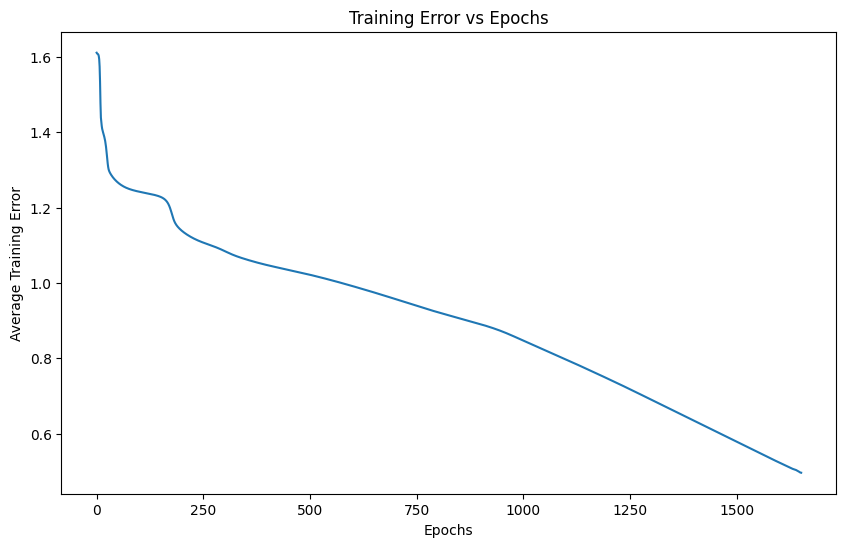

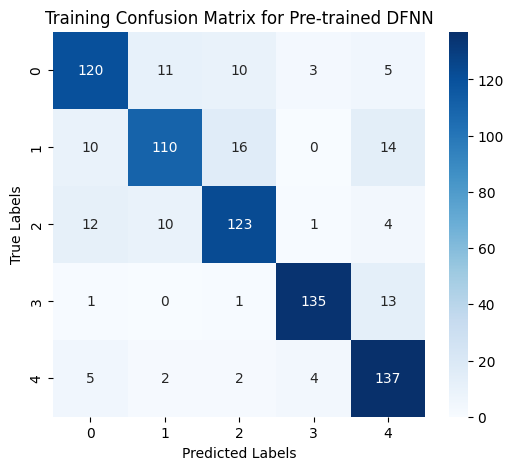

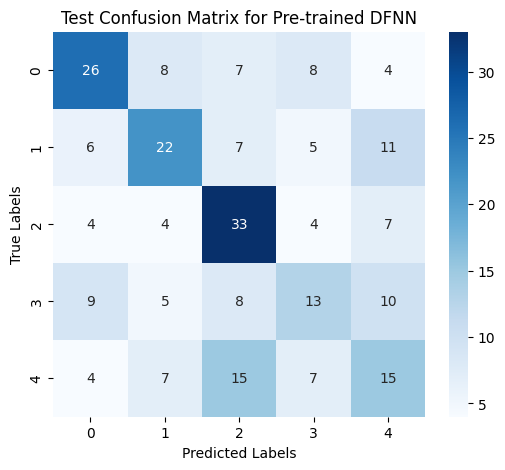

In [ ]:
input_dim = 36
hidden_dims = [20,15,10]
bottleneck_dims = [34, 32, 30]
output_dim = 30
label_count = 5


# Train first autoencoder
torch.manual_seed(42)
encoder1 = train_autoencoder(Autoencoder(input_dim, hidden_dims[0], bottleneck_dims[0]), train_unlabel_loader)

# Encode the dataset using the first encoder
encoded_data1 = []
for batch in train_unlabel_loader:
    encoded_batch= encoder1(batch[0])
    encoded_data1.append(encoded_batch)
encoded_data1 = torch.cat(encoded_data1).detach()

print(encoded_data1.shape)
# Create DataLoader for encoded_data1
encoded_data1_loader = DataLoader(TensorDataset(encoded_data1), batch_size=batch_sz, shuffle=True)

# Train second autoencoder
torch.manual_seed(42)
encoder2 = train_autoencoder(Autoencoder(bottleneck_dims[0], hidden_dims[1], bottleneck_dims[1]), encoded_data1_loader)

# Encode the dataset using the second encoder
encoded_data2 = []
for batch in encoded_data1_loader:
    encoded_batch = encoder2(batch[0])
    encoded_data2.append(encoded_batch)
encoded_data2 = torch.cat(encoded_data2).detach()

print(encoded_data2.shape)
# Create DataLoader for encoded_data2
encoded_data2_loader = DataLoader(TensorDataset(encoded_data2), batch_size=batch_sz, shuffle=True)

# Train third autoencoder
torch.manual_seed(42)
encoder3 = train_autoencoder(Autoencoder(bottleneck_dims[1], hidden_dims[2], bottleneck_dims[2]), encoded_data2_loader)


torch.manual_seed(42)
dfnn_pretrained = DFNN(input_dim, hidden_dims, output_dim, label_count)


dfnn_pretrained.fc1.weight.data = encoder1[0].weight.data.clone()


dfnn_pretrained.fc2.weight.data = torch.matmul(
    encoder1[2].weight.data.T,
    encoder2[0].weight.data.transpose(0,1)
).T

dfnn_pretrained.fc3.weight.data = torch.matmul(
    encoder2[2].weight.data.T,
    encoder3[0].weight.data.transpose(0, 1)
).T

dfnn_pretrained.fc4.weight.data = encoder3[2].weight.data.clone()


print("[+] Training pre-trained DFNN")
# print(dfnn_pretrained.state_dict())
dfnn_pretrained = train_dfnn(dfnn_pretrained, train_loader)
train_confusion1 = evaluate_model(dfnn_pretrained, x_train, y_train)
test_confusion1 = evaluate_model(dfnn_pretrained, x_test, y_test)
val_confusion1 = evaluate_model(dfnn_pretrained, x_val, y_val)


plt.figure(figsize=(6, 5))
sns.heatmap(train_confusion1, annot=True, fmt="d", cmap="Blues")
plt.title("Training Confusion Matrix for Pre-trained DFNN")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(test_confusion1, annot=True, fmt="d", cmap="Blues")
plt.title("Test Confusion Matrix for Pre-trained DFNN")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


## DFNN without pre-training

[+] Training DFNN from scratch
Accuracy 0.8678237650200267
Accuracy 0.3895582329317269
Accuracy 0.41365461847389556


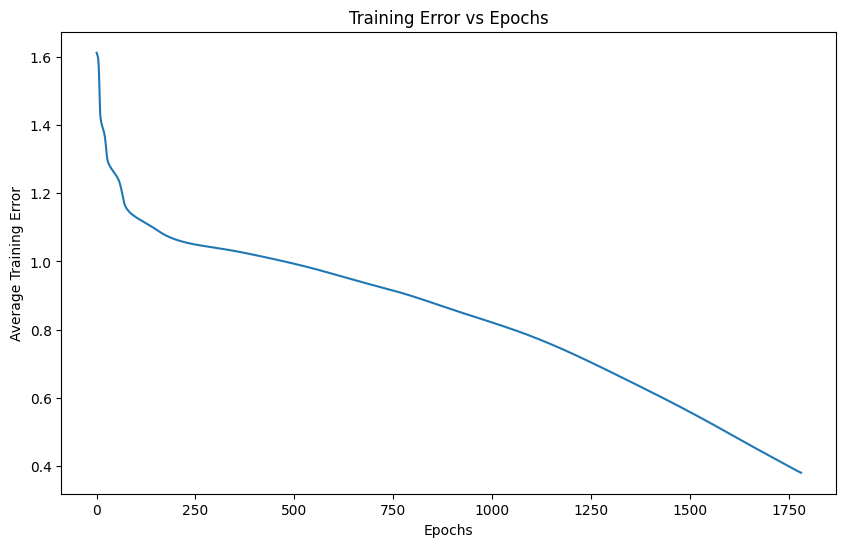

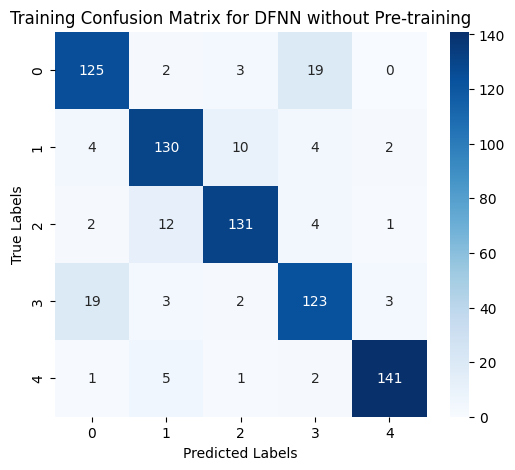

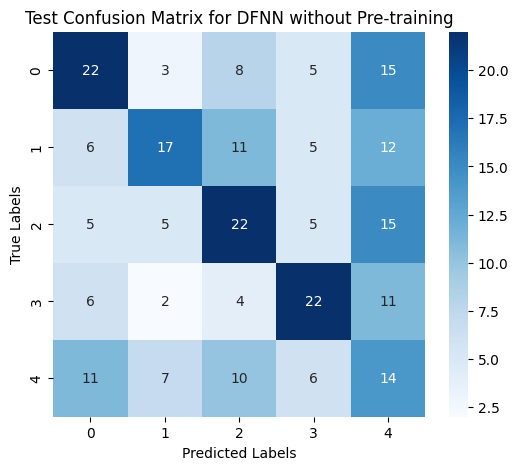

In [ ]:
print("[+] Training DFNN from scratch")
torch.manual_seed(42)
dfnn = DFNN(input_dim, hidden_dims, output_dim, label_count)
#print(dfnn.state_dict())
dfnn = train_dfnn(dfnn, train_loader)
train_confusion2 = evaluate_model(dfnn, x_train, y_train)
test_confusion2 = evaluate_model(dfnn, x_test, y_test)
val_confusion2 = evaluate_model(dfnn, x_val, y_val)

plt.figure(figsize=(6, 5))
sns.heatmap(train_confusion2, annot=True, fmt="d", cmap="Blues")
plt.title("Training Confusion Matrix for DFNN without Pre-training")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(test_confusion2, annot=True, fmt="d", cmap="Blues")
plt.title("Test Confusion Matrix for DFNN without Pre-training")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

### With node as 20

- val accuracy with pre-trained: 0.4457831325301205
- val accuracy: 0.42570281124497994

### With node as 22
- Accuracy 0.4497991967871486

### WIth node as 20 10 20
- Accuracy 0.46987951807228917
- Accuracy 0.41767068273092367


### with node as 20 15 20
- Accuracy 0.43775100401606426
- Accuracy 0.40160642570281124

### with node as 20 15 10
- High Training accuracy as well.
- Accuracy 0.46586345381526106
- Accuracy 0.41365461847389556